# Parametric Surrogate Model — Deep Tunnel PINN

**Approach:** Train 9 separate PINNs on a grid of material parameters, then interpolate network weights to predict displacement fields for any intermediate (E, ν).

| Parameter | Training values |
|---|---|
| E (Young's modulus) | 10, 20, 30 MPa |
| ν (Poisson's ratio) | 0.1, 0.2, 0.3 |

**Output:** Full displacement field (u, v) at any (x, y) in the domain.

## 1. Imports & Setup

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import json
from itertools import product
from matplotlib.path import Path
from matplotlib.patches import Wedge
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from scipy.interpolate import RegularGridInterpolator

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.set_default_tensor_type(torch.FloatTensor)

# ============================================================
# PARAMETER GRID  — edit these to change the surrogate space
# ============================================================
E_VALUES  = [10.0, 20.0, 30.0]   # MPa
NU_VALUES = [0.1,  0.2,  0.3]

# Training config
N_EPOCHS  = 100   # per case (reduce for quick tests, e.g. 5000)
LR        = 0.001

# Domain & load
R_TUNNEL  = 1.0     # tunnel radius [m]
LOAD_X0   = 0.0
LOAD_X1   = 4.0
LOAD_VAL  = -0.120  # [MPa] compression

SAVE_DIR  = "surrogate_weights"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Will train {len(E_VALUES)}×{len(NU_VALUES)} = {len(E_VALUES)*len(NU_VALUES)} cases")

Using device: cpu
Will train 3×3 = 9 cases


## 2. Network Architecture

In [10]:
class Net(nn.Module):
    """Same architecture for every case — required for weight interpolation."""
    def __init__(self):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(2, 128)
        self.hidden2 = nn.Linear(128, 128)
        self.hidden3 = nn.Linear(128, 128)
        self.hidden4 = nn.Linear(128, 128)
        self.hidden5 = nn.Linear(128, 128)
        self.output  = nn.Linear(128, 2)

    def forward(self, x):
        x = torch.tanh(self.hidden1(x))
        x = torch.tanh(self.hidden2(x))
        x = torch.tanh(self.hidden3(x))
        x = torch.tanh(self.hidden4(x))
        x = torch.tanh(self.hidden5(x))
        return self.output(x)

## 3. Domain Definition & Boundary Detection

In [11]:
# Quarter-domain with circular tunnel cutout
R = R_TUNNEL

verts = [
    (R, 0), (4, 0), (4, 4), (0, 4), (0, R),
    (0, R*(1-0.5523)), (R*(1-0.5523), 0), (R, 0), (R, 0),
]
codes = [
    Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.LINETO,
    Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY,
]
path = Path(verts, codes)

def in_domain(x, y):
    pts = np.column_stack((x.cpu().numpy(), y.cpu().numpy()))
    return torch.tensor(path.contains_points(pts), dtype=torch.bool, device=device)

# Boundary masks
def BC_bottom(x, y):
    tol = 1e-6
    return ((torch.abs(y) < tol) & (x >= 1.0) & (x <= 4.0)).squeeze()

def BC_left(x, y):
    tol = 1e-6
    return ((torch.abs(x) < tol) & (y >= 1.0) & (y <= 4.0)).squeeze()

def BC_top(x, y):
    tol = 1e-6
    return ((torch.abs(y - 4) < tol) & (x >= 0) & (x <= 4.0)).squeeze()

def BC_right(x, y):
    tol = 1e-6
    return ((torch.abs(x - 4.0) < tol) & (y >= 0) & (y <= 4.0)).squeeze()

def BC_curved(x, y):
    tol = 0.005
    r = torch.sqrt(x**2 + y**2)
    return ((torch.abs(r - 1.0) < tol) & (x >= 0) & (y >= 0) & (x <= 1.0) & (y <= 1.0)).squeeze()

## 4. Parameterised PDE & BC Losses

Key change from original: `E` and `nu` are **function arguments**, not global constants.

In [12]:
def constitutive_coeffs(E, nu):
    """Plane-strain constitutive coefficients."""
    C11 = E * (1 - nu) / ((1 + nu) * (1 - 2*nu))
    C12 = E * nu       / ((1 + nu) * (1 - 2*nu))
    C33 = E            / (2 * (1 + nu))
    return C11, C12, C33


def _stress_from_grad(xy_pts, net, C11, C12, C33):
    out  = net(xy_pts)
    u, v = out[:, 0:1], out[:, 1:2]
    grads_u = torch.autograd.grad(u.sum(), xy_pts, create_graph=True)[0]
    grads_v = torch.autograd.grad(v.sum(), xy_pts, create_graph=True)[0]
    u_x, u_y = grads_u[:, 0], grads_u[:, 1]
    v_x, v_y = grads_v[:, 0], grads_v[:, 1]
    s_xx = C11 * u_x + C12 * v_y
    s_yy = C12 * u_x + C11 * v_y
    s_xy = C33 * (u_y + v_x)
    return s_xx, s_yy, s_xy


def BC_loss(xy, net, E, nu):
    """Boundary condition loss — parameterised by (E, nu)."""
    C11, C12, C33 = constitutive_coeffs(E, nu)
    x = xy[:, 0].unsqueeze(1)
    y = xy[:, 1].unsqueeze(1)
    out = net(xy)
    u, v = out[:, 0:1], out[:, 1:2]

    bc_b = BC_bottom(x, y)
    bc_l = BC_left(x, y)
    bc_r = BC_right(x, y)
    bc_t = BC_top(x, y)
    bc_c = BC_curved(x, y)

    loss = torch.tensor(0.0, device=xy.device)

    # Bottom: v = 0, sigma_xy = 0
    if bc_b.any():
        loss += F.mse_loss(v[bc_b], torch.zeros_like(v[bc_b]))
        xy_b = xy[bc_b].detach().requires_grad_(True)
        _, _, s_xy_b = _stress_from_grad(xy_b, net, C11, C12, C33)
        loss += F.mse_loss(s_xy_b, torch.zeros_like(s_xy_b))

    # Left: u = 0, sigma_xy = 0
    if bc_l.any():
        loss += F.mse_loss(u[bc_l], torch.zeros_like(u[bc_l]))
        xy_l = xy[bc_l].detach().requires_grad_(True)
        _, _, s_xy_l = _stress_from_grad(xy_l, net, C11, C12, C33)
        loss += F.mse_loss(s_xy_l, torch.zeros_like(s_xy_l))

    # Right: u = 0, sigma_xy = 0
    if bc_r.any():
        loss += F.mse_loss(u[bc_r], torch.zeros_like(u[bc_r]))
        xy_r = xy[bc_r].detach().requires_grad_(True)
        _, _, s_xy_r = _stress_from_grad(xy_r, net, C11, C12, C33)
        loss += F.mse_loss(s_xy_r, torch.zeros_like(s_xy_r))

    # Top: sigma_xy = 0, sigma_yy = LOAD_VAL on [LOAD_X0, LOAD_X1]
    if bc_t.any():
        xy_t = xy[bc_t].detach().requires_grad_(True)
        x_t  = xy_t[:, 0]
        _, s_yy_t, s_xy_t = _stress_from_grad(xy_t, net, C11, C12, C33)
        loss += F.mse_loss(s_xy_t, torch.zeros_like(s_xy_t))
        load_mask = (x_t >= LOAD_X0) & (x_t <= LOAD_X1)
        if (~load_mask).any():
            loss += F.mse_loss(s_yy_t[~load_mask], torch.zeros_like(s_yy_t[~load_mask]))
        if load_mask.any():
            loss += F.mse_loss(s_yy_t[load_mask], LOAD_VAL * torch.ones_like(s_yy_t[load_mask]))

    # Curved wall: traction-free
    if bc_c.any():
        xy_c = xy[bc_c].detach().requires_grad_(True)
        x_c, y_c = xy_c[:, 0], xy_c[:, 1]
        r_c = torch.sqrt(x_c**2 + y_c**2).clamp(min=1e-8)
        nx_c, ny_c = x_c / r_c, y_c / r_c
        s_xx_c, s_yy_c, s_xy_c = _stress_from_grad(xy_c, net, C11, C12, C33)
        t_x = s_xx_c * nx_c + s_xy_c * ny_c
        t_y = s_xy_c * nx_c + s_yy_c * ny_c
        loss += F.mse_loss(t_x, torch.zeros_like(t_x))
        loss += F.mse_loss(t_y, torch.zeros_like(t_y))

    return loss


def PDE_loss(x, y, net, E, nu):
    """Equilibrium PDE loss — parameterised by (E, nu)."""
    x_r = x.unsqueeze(1) if x.dim() == 1 else x
    y_r = y.unsqueeze(1) if y.dim() == 1 else y
    xy = torch.cat([x_r, y_r], dim=1)
    xy.requires_grad = True

    out = net(xy)
    u, v = out[:, 0:1], out[:, 1:2]

    u_x = torch.autograd.grad(u.sum(), xy, create_graph=True)[0][:, 0:1]
    u_y = torch.autograd.grad(u.sum(), xy, create_graph=True)[0][:, 1:2]
    v_x = torch.autograd.grad(v.sum(), xy, create_graph=True)[0][:, 0:1]
    v_y = torch.autograd.grad(v.sum(), xy, create_graph=True)[0][:, 1:2]

    lam = E * nu / ((1+nu)*(1-2*nu))
    mu  = E / (2*(1+nu))

    sigma_xx = (lam + 2*mu)*u_x + lam*v_y
    sigma_yy = lam*u_x + (lam + 2*mu)*v_y
    sigma_xy = mu*(u_y + v_x)

    R_x = (torch.autograd.grad(sigma_xx.sum(), xy, create_graph=True)[0][:, 0:1]
         + torch.autograd.grad(sigma_xy.sum(), xy, create_graph=True)[0][:, 1:2])
    R_y = (torch.autograd.grad(sigma_xy.sum(), xy, create_graph=True)[0][:, 0:1]
         + torch.autograd.grad(sigma_yy.sum(), xy, create_graph=True)[0][:, 1:2])

    return F.mse_loss(R_x, torch.zeros_like(R_x)), F.mse_loss(R_y, torch.zeros_like(R_y))

## 5. Collocation Point Sampling

Generating collocation points (shared for all cases)...


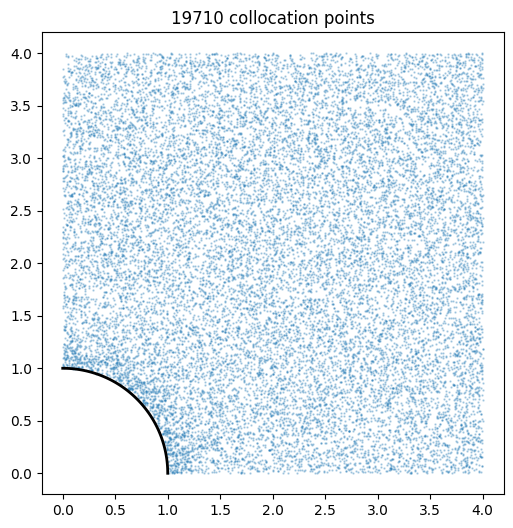

Interior: 19710,  Boundary: 5000


In [13]:
def generate_point_distribution(nx=100, ny=100, arc_density=10, arc_influence=1.2, plot=False):
    x_min, x_max = 0.0, 4.0
    y_min, y_max = 0.0, 4.0
    R = 1.0

    num_random = nx * ny * 5
    x_r = torch.rand(num_random, device=device) * (x_max - x_min) + x_min
    y_r = torch.rand(num_random, device=device) * (y_max - y_min) + y_min

    dist = torch.sqrt(x_r**2 + y_r**2)
    invalid = (x_r < R) & (y_r < R) & (dist < R)
    valid = ~invalid
    x_r, y_r, dist = x_r[valid], y_r[valid], dist[valid]

    dist_to_arc = torch.abs(dist - R)
    arc_wt = (x_r < R*1.5) & (y_r < R*1.5)
    not_on = dist_to_arc > 0.01

    base_prob = 0.4
    prob_arc = arc_influence / (1 + (dist_to_arc * arc_density)**2)
    prob_arc = prob_arc * arc_wt.float() * not_on.float()
    keep_prob = torch.clamp(base_prob + prob_arc, 0, 1)
    keep = torch.rand(len(x_r), device=device) < keep_prob

    x_f, y_f = x_r[keep], y_r[keep]

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(x_f.cpu(), y_f.cpu(), s=0.5, alpha=0.3)
        theta = np.linspace(0, np.pi/2, 100)
        plt.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)
        plt.gca().set_aspect('equal')
        plt.title(f'{len(x_f)} collocation points')
        plt.show()

    return x_f, y_f


def generate_boundary_points(n=1000):
    x_b = torch.cat([
        torch.linspace(1.0, 4.0, n, device=device),   # bottom
        torch.zeros(n, device=device),                  # left
        torch.linspace(0, 4.0, n, device=device),      # top
        torch.ones(n, device=device) * 4.0,             # right
        torch.cos(torch.linspace(0, torch.pi/2, n, device=device)),  # arc
    ])
    y_b = torch.cat([
        torch.zeros(n, device=device),
        torch.linspace(1.0, 4.0, n, device=device),
        torch.ones(n, device=device) * 4.0,
        torch.linspace(0, 4.0, n, device=device),
        torch.sin(torch.linspace(0, torch.pi/2, n, device=device)),
    ])
    return torch.stack([x_b, y_b], dim=1)


# Pre-generate points (shared across all 9 cases)
print("Generating collocation points (shared for all cases)...")
x_inner, y_inner = generate_point_distribution(plot=True)
xy_boundary = generate_boundary_points()
print(f"Interior: {len(x_inner)},  Boundary: {len(xy_boundary)}")

## 6. Train One Case

In [14]:
def train_single_case(E, nu, n_epochs=N_EPOCHS, lr=LR, verbose_every=2000):
    """
    Train a PINN for a single (E, nu) combination.
    Returns the trained network and loss history.
    """
    torch.manual_seed(0)  # same init for every case → smoother interpolation
    net = Net().to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-4)

    best_loss = float('inf')
    best_state = None
    history = {'total': [], 'pde_x': [], 'pde_y': [], 'bc': []}

    pbar = tqdm(range(n_epochs), desc=f"E={E}, ν={nu}", unit="ep", leave=False)
    for epoch in pbar:
        optimizer.zero_grad()

        lx, ly = PDE_loss(x_inner, y_inner, net, E, nu)
        lbc     = BC_loss(xy_boundary, net, E, nu)
        loss    = lx + ly + lbc

        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=0.5)
        optimizer.step()
        scheduler.step()

        history['total'].append(loss.item())
        history['pde_x'].append(lx.item())
        history['pde_y'].append(ly.item())
        history['bc'].append(lbc.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(net.state_dict())

        if (epoch+1) % verbose_every == 0:
            pbar.set_postfix(loss=f"{loss.item():.2e}", best=f"{best_loss:.2e}")

    pbar.close()
    net.load_state_dict(best_state)
    print(f"  E={E:5.1f}, ν={nu:.1f}  →  best loss = {best_loss:.4e}")
    return net, history

## 7. Train All 9 Cases & Save Weights

In [15]:
all_weights = {}   # key = (E, nu) → state_dict
all_history = {}

print("="*60)
print("TRAINING 9 PARAMETRIC CASES")
print("="*60)

for i, (E_val, nu_val) in enumerate(product(E_VALUES, NU_VALUES)):
    print(f"\n[{i+1}/9] Training E={E_val} MPa, ν={nu_val} ...")

    net_trained, hist = train_single_case(E_val, nu_val)

    # Save individually
    fname = os.path.join(SAVE_DIR, f"pinn_E{E_val:.0f}_nu{nu_val*10:.0f}.pth")
    torch.save(net_trained.state_dict(), fname)

    all_weights[(E_val, nu_val)] = copy.deepcopy(net_trained.state_dict())
    all_history[(E_val, nu_val)] = hist

# Save master archive
torch.save({
    'E_values': E_VALUES,
    'nu_values': NU_VALUES,
    'weights': all_weights,
}, os.path.join(SAVE_DIR, 'surrogate_archive.pth'))

print("\n" + "="*60)
print("ALL 9 CASES TRAINED & SAVED")
print("="*60)

TRAINING 9 PARAMETRIC CASES

[1/9] Training E=10.0 MPa, ν=0.1 ...


KeyboardInterrupt: 

## 8. Loss History Comparison

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for idx, (E_val, nu_val) in enumerate(product(E_VALUES, NU_VALUES)):
    ax = axes[idx // 3, idx % 3]
    h = all_history[(E_val, nu_val)]
    ax.semilogy(h['total'], 'b-', lw=0.5, alpha=0.7, label='Total')
    ax.semilogy(h['bc'],    'r-', lw=0.5, alpha=0.5, label='BC')
    ax.set_title(f'E={E_val}, ν={nu_val}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

fig.suptitle('Training Loss — All 9 Cases', fontsize=14)
fig.supxlabel('Epoch')
fig.supylabel('Loss')
plt.tight_layout()
plt.savefig('loss_all_cases.png', dpi=150)
plt.show()

## 9. Weight-Space Interpolation Engine

For any new `(E_new, ν_new)` within the trained grid, we interpolate **every weight & bias tensor** independently using `scipy.interpolate.RegularGridInterpolator` (bilinear on the 3×3 grid).

In [ ]:
class ParametricSurrogate:
    """
    Surrogate that interpolates PINN weights in (E, nu) space.
    
    Usage:
        surrogate = ParametricSurrogate('surrogate_weights/surrogate_archive.pth')
        net = surrogate.get_net(E=15.0, nu=0.25)
        uv  = net(xy_tensor)   # → (u, v) displacements
    """

    def __init__(self, archive_path):
        archive = torch.load(archive_path, map_location=device, weights_only=False)
        self.E_vals  = np.array(archive['E_values'])
        self.nu_vals = np.array(archive['nu_values'])
        self.weights = archive['weights']

        # Collect all parameter names from one model
        sample_key = list(self.weights.keys())[0]
        self.param_names = list(self.weights[sample_key].keys())

        # Build interpolators: one per flattened-weight element
        self._build_interpolators()

    def _build_interpolators(self):
        """Pre-build RegularGridInterpolators for every parameter tensor."""
        self.interpolators = {}
        self.shapes = {}

        nE  = len(self.E_vals)
        nNu = len(self.nu_vals)

        for pname in self.param_names:
            # Collect values on the grid
            sample = self.weights[list(self.weights.keys())[0]][pname]
            flat_len = sample.numel()
            self.shapes[pname] = sample.shape

            # grid_data shape: (nE, nNu, flat_len)
            grid_data = np.zeros((nE, nNu, flat_len), dtype=np.float32)
            for i, E_v in enumerate(self.E_vals):
                for j, nu_v in enumerate(self.nu_vals):
                    w = self.weights[(E_v, nu_v)][pname]
                    grid_data[i, j, :] = w.cpu().numpy().flatten()

            # One interpolator per element (vectorised below)
            self.interpolators[pname] = RegularGridInterpolator(
                (self.E_vals, self.nu_vals),
                grid_data,
                method='linear',
                bounds_error=False,
                fill_value=None,   # allows nearest-neighbour extrapolation
            )

    def get_state_dict(self, E_new, nu_new):
        """Interpolate a full state_dict for arbitrary (E, nu)."""
        point = np.array([[E_new, nu_new]])
        new_sd = {}
        for pname in self.param_names:
            vals = self.interpolators[pname](point)[0]  # shape (flat_len,)
            new_sd[pname] = torch.tensor(
                vals.reshape(self.shapes[pname]),
                dtype=torch.float32, device=device
            )
        return new_sd

    def get_net(self, E_new, nu_new):
        """Return a ready-to-use Net with interpolated weights."""
        net = Net().to(device)
        net.load_state_dict(self.get_state_dict(E_new, nu_new))
        net.eval()
        return net


# Instantiate the surrogate
surrogate = ParametricSurrogate(os.path.join(SAVE_DIR, 'surrogate_archive.pth'))
print("Surrogate loaded — ready to interpolate!")
print(f"  E  range: [{surrogate.E_vals.min()}, {surrogate.E_vals.max()}] MPa")
print(f"  ν  range: [{surrogate.nu_vals.min()}, {surrogate.nu_vals.max()}]")

## 10. Predict & Visualise for Any (E, ν)

In [ ]:
def predict_and_plot(surrogate, E_query, nu_query, nx_plot=200, ny_plot=200):
    """
    Get interpolated PINN for (E_query, nu_query) and plot full displacement field.
    """
    net = surrogate.get_net(E_query, nu_query)
    C11, C12, C33 = constitutive_coeffs(E_query, nu_query)

    X_lin = torch.linspace(0, 4.0, nx_plot, device=device)
    Y_lin = torch.linspace(0, 4.0, ny_plot, device=device)
    xx, yy = torch.meshgrid(X_lin, Y_lin, indexing='ij')
    X_flat, Y_flat = xx.flatten(), yy.flatten()
    mask_np = in_domain(X_flat, Y_flat).cpu().numpy()

    XY = torch.stack([X_flat, Y_flat], dim=1)
    XY.requires_grad_(True)

    with torch.enable_grad():
        out = net(XY)
        U, V = out[:, 0:1], out[:, 1:2]
        grads_U = torch.autograd.grad(U.sum(), XY, create_graph=True)[0]
        grads_V = torch.autograd.grad(V.sum(), XY, create_graph=True)[0]
        s_xx = C11 * grads_U[:, 0] + C12 * grads_V[:, 1]
        s_yy = C12 * grads_U[:, 0] + C11 * grads_V[:, 1]
        s_xy = C33 * (grads_U[:, 1] + grads_V[:, 0])

    U_np  = U.detach().cpu().numpy().squeeze()
    V_np  = V.detach().cpu().numpy().squeeze()
    mag   = np.sqrt(U_np**2 + V_np**2)
    sxx   = s_xx.detach().cpu().numpy() * 1000
    syy   = s_yy.detach().cpu().numpy() * 1000
    sxy   = s_xy.detach().cpu().numpy() * 1000

    X_1d = X_lin.cpu().numpy()
    Y_1d = Y_lin.cpu().numpy()

    def to_masked(arr):
        return np.ma.masked_array(arr.reshape(nx_plot, ny_plot).T,
                                  mask=~mask_np.reshape(nx_plot, ny_plot).T)

    fields = [
        (U_np,  'u_x [m]',       'u_x'),
        (V_np,  'u_y [m]',       'u_y'),
        (mag,   '|u| [m]',       '|u|'),
        (sxx,   'σ_xx [kPa]',    'σ_xx'),
        (syy,   'σ_yy [kPa]',    'σ_yy'),
        (sxy,   'σ_xy [kPa]',    'σ_xy'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    for ax, (arr, label, title) in zip(axes.flatten(), fields):
        pcm = ax.pcolormesh(X_1d, Y_1d, to_masked(arr), shading='auto', cmap='jet')
        fig.colorbar(pcm, ax=ax, label=label)
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.add_patch(Wedge((0,0), R_TUNNEL, 0, 90, fc='white', ec='none', zorder=5))
        theta = np.linspace(0, np.pi/2, 300)
        ax.plot(R_TUNNEL*np.cos(theta), R_TUNNEL*np.sin(theta), 'k-', lw=1.5, zorder=6)
        ax.plot([R_TUNNEL,4],[0,0],'k-',lw=1,zorder=6)
        ax.plot([4,4],[0,4],'k-',lw=1,zorder=6)
        ax.plot([4,0],[4,4],'k-',lw=1,zorder=6)
        ax.plot([0,0],[4,R_TUNNEL],'k-',lw=1,zorder=6)
        ax.set_xlim(0,4); ax.set_ylim(0,4)

    is_trained = (E_query in E_VALUES) and (nu_query in NU_VALUES)
    tag = "TRAINED" if is_trained else "INTERPOLATED"
    fig.suptitle(f'Deep Tunnel PINN  —  E={E_query} MPa, ν={nu_query}  [{tag}]', fontsize=14)
    plt.tight_layout()
    plt.show()

    return net

### 10a. Verify a trained case (should match original)

In [ ]:
# Verify: this should reproduce the training result exactly
_ = predict_and_plot(surrogate, E_query=20.0, nu_query=0.3)

### 10b. Interpolated predictions (NEW parameter values)

In [ ]:
# Interpolated: E = 15 MPa, nu = 0.25  (not in training set!)
_ = predict_and_plot(surrogate, E_query=15.0, nu_query=0.25)

In [ ]:
# Another interpolated case
_ = predict_and_plot(surrogate, E_query=25.0, nu_query=0.15)

## 11. Displacement Comparison Across Parameter Space

In [ ]:
def compare_displacement_at_point(surrogate, x_pt, y_pt,
                                   E_range=None, nu_range=None, n_interp=20):
    """
    Plot how (u, v) at a fixed spatial point varies across the parameter space.
    Trained grid points shown as markers; interpolated shown as surface.
    """
    if E_range is None:
        E_range = (surrogate.E_vals.min(), surrogate.E_vals.max())
    if nu_range is None:
        nu_range = (surrogate.nu_vals.min(), surrogate.nu_vals.max())

    E_fine  = np.linspace(E_range[0], E_range[1], n_interp)
    nu_fine = np.linspace(nu_range[0], nu_range[1], n_interp)

    xy_pt = torch.tensor([[x_pt, y_pt]], dtype=torch.float32, device=device)

    U_grid = np.zeros((n_interp, n_interp))
    V_grid = np.zeros((n_interp, n_interp))

    for i, E_v in enumerate(E_fine):
        for j, nu_v in enumerate(nu_fine):
            net = surrogate.get_net(float(E_v), float(nu_v))
            with torch.no_grad():
                out = net(xy_pt)
            U_grid[i, j] = out[0, 0].item()
            V_grid[i, j] = out[0, 1].item()

    EE, NN = np.meshgrid(E_fine, nu_fine, indexing='ij')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, label in zip(axes, [U_grid, V_grid], ['u_x', 'u_y']):
        c = ax.contourf(EE, NN, data, levels=30, cmap='RdBu_r')
        fig.colorbar(c, ax=ax, label=f'{label} [m]')

        # Mark trained points
        for E_t in surrogate.E_vals:
            for nu_t in surrogate.nu_vals:
                ax.plot(E_t, nu_t, 'k^', ms=8, zorder=5)

        ax.set_xlabel('E [MPa]')
        ax.set_ylabel('ν')
        ax.set_title(f'{label} at ({x_pt}, {y_pt})')

    plt.suptitle(f'Surrogate Response Surface at (x={x_pt}, y={y_pt})', fontsize=13)
    plt.tight_layout()
    plt.show()


# Example: displacement at tunnel crown (0, 1)
compare_displacement_at_point(surrogate, x_pt=0.0, y_pt=1.0)

# Example: displacement at top centre (2, 4)
compare_displacement_at_point(surrogate, x_pt=2.0, y_pt=4.0)

## 12. Quick Prediction API

For downstream use — pass any `(E, nu, x, y)` and get `(u, v)`.

In [ ]:
def predict_displacement(surrogate, E, nu, x, y):
    """
    Quick API: predict displacements for arbitrary parameters and coordinates.
    
    Parameters
    ----------
    E  : float    — Young's modulus [MPa],  within [10, 30]
    nu : float    — Poisson's ratio,        within [0.1, 0.3]
    x  : float or array-like  — x-coordinates [m]
    y  : float or array-like  — y-coordinates [m]
    
    Returns
    -------
    u, v : numpy arrays of displacements
    """
    net = surrogate.get_net(E, nu)
    
    x_t = torch.tensor(np.atleast_1d(x), dtype=torch.float32, device=device)
    y_t = torch.tensor(np.atleast_1d(y), dtype=torch.float32, device=device)
    xy  = torch.stack([x_t, y_t], dim=1)
    
    with torch.no_grad():
        out = net(xy)
    
    return out[:, 0].cpu().numpy(), out[:, 1].cpu().numpy()


# ── Demo ──────────────────────────────────────────────────────
u, v = predict_displacement(surrogate, E=15.0, nu=0.25, x=[0.0, 1.0, 2.0], y=[1.0, 1.0, 1.0])
print("Interpolated prediction at E=15 MPa, ν=0.25:")
for i, (xi, yi) in enumerate(zip([0,1,2], [1,1,1])):
    print(f"  ({xi}, {yi}) → u={u[i]:.6f}, v={v[i]:.6f}")

---
## Summary

| Component | Description |
|---|---|
| **Training** | 9 PINNs trained independently (same init seed) |
| **Storage** | `surrogate_weights/surrogate_archive.pth` (~50 MB) |
| **Interpolation** | Bilinear in weight space via `RegularGridInterpolator` |
| **Prediction** | `predict_displacement(surrogate, E, nu, x, y)` |
| **Valid range** | E ∈ [10, 30] MPa,  ν ∈ [0.1, 0.3] |

In [ ]:
import pandas as pd

def save_fields_to_csv(surrogate, E_query, nu_query, nx_plot=200, ny_plot=200,
                        filename='results_fields.csv'):
    """
    Predict and save ux, uy, sigma_xx, sigma_yy, sigma_xy to a CSV file.

    Parameters
    ----------
    surrogate : ParametricSurrogate
    E_query   : float — Young's modulus [MPa]
    nu_query  : float — Poisson's ratio
    nx_plot   : int   — grid resolution in x
    ny_plot   : int   — grid resolution in y
    filename  : str   — output CSV filename
    """
    net = surrogate.get_net(E_query, nu_query)
    C11, C12, C33 = constitutive_coeffs(E_query, nu_query)

    X_lin = torch.linspace(0, 4.0, nx_plot, device=device)
    Y_lin = torch.linspace(0, 4.0, ny_plot, device=device)
    xx, yy = torch.meshgrid(X_lin, Y_lin, indexing='ij')
    X_flat, Y_flat = xx.flatten(), yy.flatten()
    mask = in_domain(X_flat, Y_flat).cpu().numpy()

    XY = torch.stack([X_flat, Y_flat], dim=1)
    XY.requires_grad_(True)

    with torch.enable_grad():
        out = net(XY)
        U, V = out[:, 0:1], out[:, 1:2]
        grads_U = torch.autograd.grad(U.sum(), XY, create_graph=True)[0]
        grads_V = torch.autograd.grad(V.sum(), XY, create_graph=True)[0]
        s_xx = (C11 * grads_U[:, 0] + C12 * grads_V[:, 1]).detach().cpu().numpy()
        s_yy = (C12 * grads_U[:, 0] + C11 * grads_V[:, 1]).detach().cpu().numpy()
        s_xy = (C33 * (grads_U[:, 1] + grads_V[:, 0])).detach().cpu().numpy()

    ux_np = U.detach().cpu().numpy().squeeze()
    uy_np = V.detach().cpu().numpy().squeeze()
    x_np  = X_flat.cpu().numpy()
    y_np  = Y_flat.cpu().numpy()

    df = pd.DataFrame({
        'x':        x_np[mask],
        'y':        y_np[mask],
        'ux':       ux_np[mask],
        'uy':       uy_np[mask],
        'sigma_xx': s_xx[mask],
        'sigma_yy': s_yy[mask],
        'sigma_xy': s_xy[mask],
    })

    df.to_csv(filename, index=False)
    print(f'Saved {len(df)} domain points to "{filename}"')
    print(df.describe())
    return df


# ── Save results for E=15 MPa, ν=0.25 ────────────────────────
df_results = save_fields_to_csv(surrogate, E_query=15.0, nu_query=0.25,
                                 filename='tunnel_E15_nu025.csv')
